# Camera → BEV segmentation — training

Stage 1: surround cameras → BEV drivable-area + vehicle segmentation, metric BEV mIoU.

This notebook's first block is **data loading**: build the train/val datasets over
nuScenes keyframes, each carrying the 6 camera images, raw per-sensor calibration,
and the precomputed BEV raster target. It stops at the `DataLoader` boundary — the
`collate_fn` (variable per-sample sensor/agent batching + masking) and the
`DataLoader` setup are written separately.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import torch

REPO_ROOT = Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from bev.data import CAMERAS, NuScenesBEVDataset, NuScenesConfig, Sample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__}  device={device}")

torch 2.9.1+cu129  device=cuda


In [2]:
# Paths and grid/target configuration.
DATAROOT = REPO_ROOT / "data" / "nuscenes"
VERSION = "v1.0-mini"
RASTER_ROOT = REPO_ROOT / "data" / "bev_rasters"

# Stage 1 is camera-only: all 6 cameras in, lidar off. The BEV target comes from
# the precomputed raster store, so annotations are not loaded at train time.
SPLITS = {"train": "mini_train", "val": "mini_val"}

In [ ]:
def build_dataset(split: str) -> NuScenesBEVDataset:
    return NuScenesBEVDataset(
        NuScenesConfig(
            dataroot=DATAROOT,
            version=VERSION,
            split=split,
            cameras=CAMERAS,
            load_lidar=False,
            load_annotations=False,
            bev_raster_root=RASTER_ROOT / split,
        )
    )


train_set = build_dataset(SPLITS["train"])
val_set = build_dataset(SPLITS["val"])
print(f"train: {len(train_set)} keyframes   val: {len(val_set)} keyframes")

train: 323 keyframes   val: 81 keyframes


## Sanity check one sample

Confirm each item carries what the model and loss expect: 6 camera tensors, raw
calibration per camera, and a `(C, H, W)` BEV raster whose layers and grid match
the store. The per-layer occupied fraction is a quick read on the BEV class
imbalance the loss has to handle.

In [4]:
sample: Sample = train_set[0]

print(f"sample_token: {sample.sample_token}")
print(f"scene:        {sample.scene_name}")
print(f"cameras:      {list(sample.cameras)}")

cam = sample.cameras[CAMERAS[0]]
print(f"\n{cam.channel}: image {tuple(cam.image.shape)} {cam.image.dtype}")
print(f"  intrinsic:\n{cam.calib.intrinsic}")
print(f"  sensor2ego t: {cam.calib.sensor2ego_translation.tolist()}")
print(f"  ego2global t: {cam.calib.ego2global_translation.tolist()}")

raster = sample.bev_raster
assert raster is not None, "bev_raster_root not wired or sample missing a raster"
data = raster.data  # (C, H, W)
print(f"\nraster: {tuple(data.shape)} {data.dtype}  layers={raster.layer_names}")
print(f"  grid: {raster.spec.nx}x{raster.spec.ny} @ {raster.spec.resolution} m")
for c, name in enumerate(raster.layer_names):
    frac = float((data[c] > 0).float().mean())
    print(f"  {name:14s} occupied {frac:6.3%}")

sample_token: cd9964f8c3d34383b16e9c2997de1ed0
scene:        scene-0757
cameras:      ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT']

CAM_FRONT_LEFT: image (3, 900, 1600) torch.uint8
  intrinsic:
tensor([[1.2579e+03, 0.0000e+00, 8.2724e+02],
        [0.0000e+00, 1.2579e+03, 4.5092e+02],
        [0.0000e+00, 0.0000e+00, 1.0000e+00]], dtype=torch.float64)
  sensor2ego t: [1.5752559464, 0.500519383135, 1.50696032589]
  ego2global t: [334.7712219122368, 658.6383442168495, 0.0]

raster: (2, 200, 200) torch.float32  layers=('drivable_area', 'vehicle')
  grid: 200x200 @ 0.5 m
  drivable_area  occupied 19.905%
  vehicle        occupied 1.250%


## DataLoaders

In [16]:
from torch.utils.data import DataLoader

from bev.data import collate_fn

TRAIN_BATCH_SIZE = 16
VAL_BATCH_SIZE = 16


train_loader = DataLoader(train_set, batch_size=TRAIN_BATCH_SIZE, shuffle=True, collate_fn=collate_fn, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=VAL_BATCH_SIZE, shuffle=True, collate_fn=collate_fn, pin_memory=True)

In [9]:
import matplotlib.pyplot as plt

# test loader
train_sample = next(iter(train_loader))
print(train_sample)

SampleBatch(camera_batch=CameraDataBatch(channels=('CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT'), images=tensor([[[[[ 0.1597,  0.1597,  0.1426,  ..., -0.8678, -0.8507, -0.8507],
           [ 0.1597,  0.1597,  0.1426,  ..., -0.8678, -0.8507, -0.8507],
           [ 0.1597,  0.1597,  0.1597,  ..., -0.8335, -0.8164, -0.8164],
           ...,
           [-0.4397, -0.4397, -0.4397,  ..., -0.3883, -0.3712, -0.3541],
           [-0.4397, -0.4397, -0.4397,  ..., -0.4054, -0.3712, -0.3712],
           [-0.4397, -0.4397, -0.4397,  ..., -0.4054, -0.3712, -0.3712]],

          [[ 0.3803,  0.3803,  0.3627,  ..., -0.8452, -0.8277, -0.8277],
           [ 0.3803,  0.3803,  0.3627,  ..., -0.8452, -0.8277, -0.8277],
           [ 0.3803,  0.3803,  0.3803,  ..., -0.8102, -0.7927, -0.7927],
           ...,
           [-0.1800, -0.1800, -0.1800,  ..., -0.1275, -0.1099, -0.0924],
           [-0.1800, -0.1800, -0.1800,  ..., -0.1450, -0.1099, -0.1099],
       

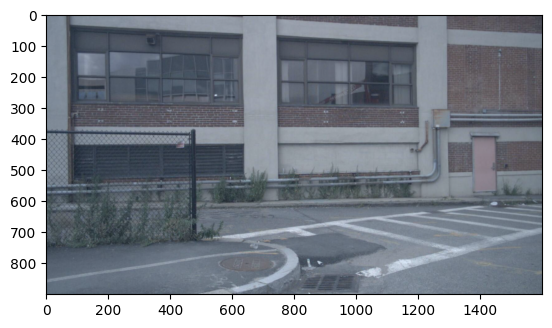

In [15]:
plt.imshow((train_sample.camera_batch.images[0,0].permute(1,2,0)-train_sample.camera_batch.images[0,0].min())/(train_sample.camera_batch.images[0,0].max()-train_sample.camera_batch.images[0,0].min()))

## Training

In [ ]:
# TODO